<a href="https://www.kaggle.com/code/pushparajput03/netflix-stock-insights-rnn-and-lstm-approach?scriptVersionId=324388795" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jainshukal/netflix-stock-price/NFLX.csv


# Import Required Libraries

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, GRU, SimpleRNN,
    Dense, Dropout, Flatten, BatchNormalization,
    GlobalAveragePooling2D, LeakyReLU
)
from tensorflow import keras 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Input, LSTM, Dense, Bidirectional, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Attention
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Attention, LSTM, Bidirectional, Dropout, BatchNormalization, Dense, Add

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import random
import seaborn as sns

2026-06-04 05:20:47.289923: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780550447.532667      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780550447.599242      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780550448.180838      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780550448.180909      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780550448.180914      16 computation_placer.cc:177] computation placer alr

# Import  Data

In [3]:
df = pd.read_csv("/kaggle/input/datasets/jainshukal/netflix-stock-price/NFLX.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-12-16,119.800003,123.000000,118.089996,122.639999,122.639999,13181000
1,2015-12-17,123.970001,126.349998,122.419998,122.510002,122.510002,17284900
2,2015-12-18,120.849998,122.190002,117.919998,118.019997,118.019997,17948100
3,2015-12-21,119.510002,119.589996,115.660004,116.629997,116.629997,11670000
4,2015-12-22,117.300003,117.430000,114.860001,116.239998,116.239998,9689000
...,...,...,...,...,...,...,...
1002,2019-12-10,296.119995,298.940002,292.019989,293.119995,293.119995,10476100
1003,2019-12-11,294.489990,299.429993,294.200012,298.929993,298.929993,5589800
1004,2019-12-12,295.670013,299.170013,295.059998,298.440002,298.440002,4766600
1005,2019-12-13,298.500000,301.799988,297.250000,298.500000,298.500000,3879700


# Pandas DtaFrame

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1007 non-null   object 
 1   Open       1007 non-null   float64
 2   High       1007 non-null   float64
 3   Low        1007 non-null   float64
 4   Close      1007 non-null   float64
 5   Adj Close  1007 non-null   float64
 6   Volume     1007 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 55.2+ KB


In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1007.000000,1007.000000,1007.000000,1007.000000,1007.000000,1.007000e+03
mean,226.708094,229.972979,223.105690,226.670159,226.670159,9.730586e+06
std,103.305422,104.851349,101.458611,103.203785,103.203785,6.398967e+06
min,80.570000,84.699997,79.949997,82.790001,82.790001,1.616300e+06
25%,125.779999,127.165001,124.355000,125.514999,125.514999,5.573200e+06
50%,197.850006,199.440002,195.330002,198.000000,198.000000,7.857600e+06
75%,325.529999,330.835006,318.869995,325.220001,325.220001,1.178630e+07
max,421.380005,423.209991,413.079987,418.970001,418.970001,5.841040e+07


In [6]:
df.shape

(1007, 7)

In [7]:
df.isna().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [8]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [9]:
df["Date"] = pd.to_datetime(df["Date"])
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-12-16,119.800003,123.000000,118.089996,122.639999,122.639999,13181000
1,2015-12-17,123.970001,126.349998,122.419998,122.510002,122.510002,17284900
2,2015-12-18,120.849998,122.190002,117.919998,118.019997,118.019997,17948100
3,2015-12-21,119.510002,119.589996,115.660004,116.629997,116.629997,11670000
4,2015-12-22,117.300003,117.430000,114.860001,116.239998,116.239998,9689000
...,...,...,...,...,...,...,...
1002,2019-12-10,296.119995,298.940002,292.019989,293.119995,293.119995,10476100
1003,2019-12-11,294.489990,299.429993,294.200012,298.929993,298.929993,5589800
1004,2019-12-12,295.670013,299.170013,295.059998,298.440002,298.440002,4766600
1005,2019-12-13,298.500000,301.799988,297.250000,298.500000,298.500000,3879700


In [10]:
group = df.groupby("Volume")
group.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-12-16,119.800003,123.000000,118.089996,122.639999,122.639999,13181000
1,2015-12-17,123.970001,126.349998,122.419998,122.510002,122.510002,17284900
2,2015-12-18,120.849998,122.190002,117.919998,118.019997,118.019997,17948100
3,2015-12-21,119.510002,119.589996,115.660004,116.629997,116.629997,11670000
4,2015-12-22,117.300003,117.430000,114.860001,116.239998,116.239998,9689000
...,...,...,...,...,...,...,...
1002,2019-12-10,296.119995,298.940002,292.019989,293.119995,293.119995,10476100
1003,2019-12-11,294.489990,299.429993,294.200012,298.929993,298.929993,5589800
1004,2019-12-12,295.670013,299.170013,295.059998,298.440002,298.440002,4766600
1005,2019-12-13,298.500000,301.799988,297.250000,298.500000,298.500000,3879700


# Exploratory Data Analysis (EDA)

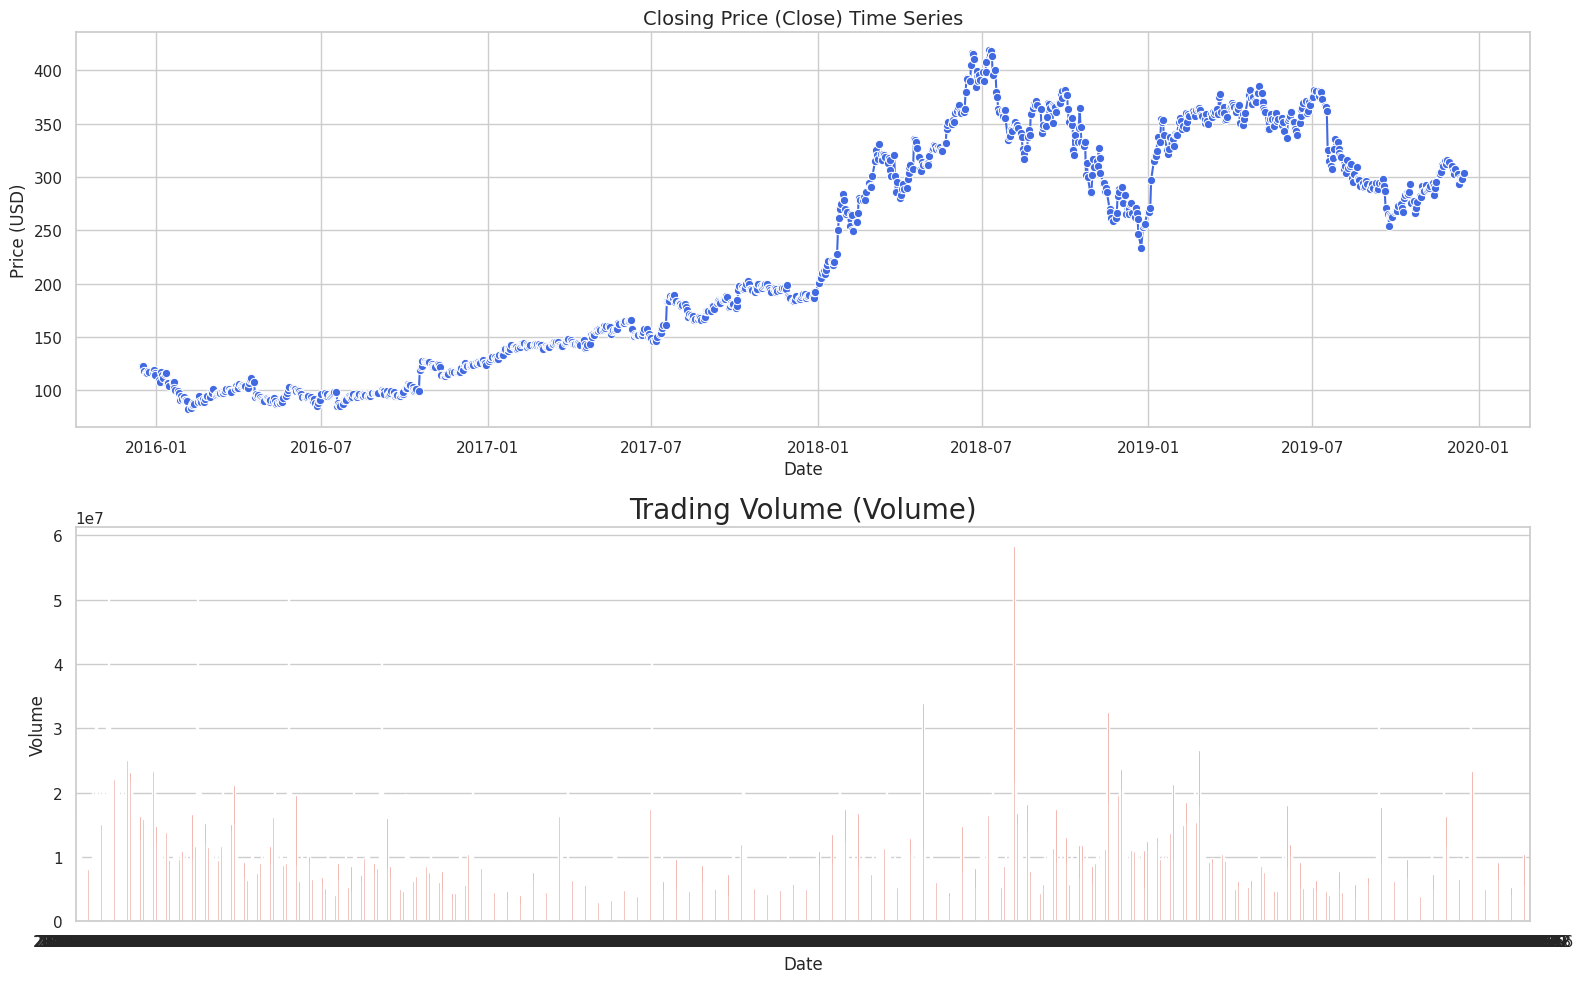

In [11]:
sns.set(style="whitegrid")
plt.figure(figsize=(16, 10))

plt.subplot(2, 1, 1)
sns.lineplot(x="Date", y="Close", data=df, marker="o", color="royalblue")
plt.title("Closing Price (Close) Time Series", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.subplot(2, 1, 2)
sns.barplot(x="Date", y="Volume", data=df, color="salmon")
plt.title("Trading Volume (Volume)", fontsize=20)
plt.xlabel("Date")
plt.ylabel("Volume")

plt.tight_layout()
plt.show()

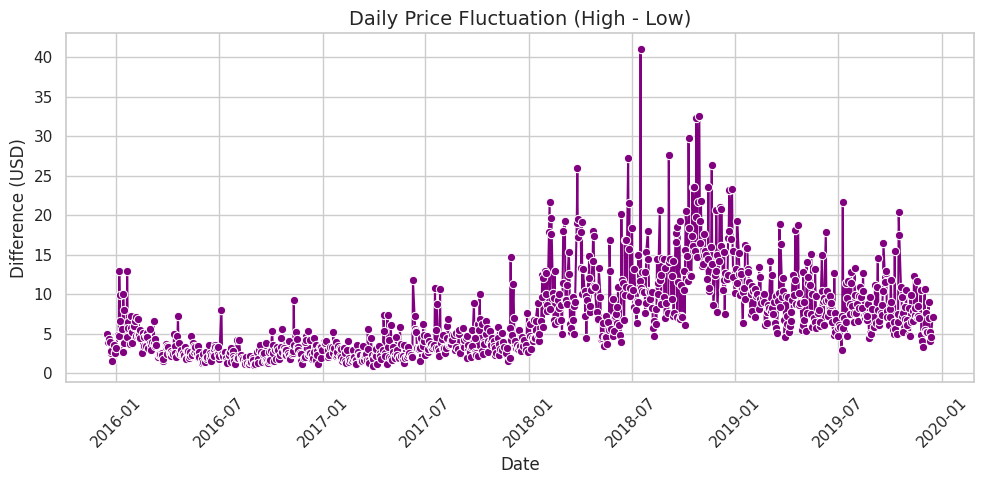

In [12]:
df["Range"] = df["High"] - df["Low"]

plt.figure(figsize=(10, 5))
sns.lineplot(x="Date", y="Range", data=df, marker='o', color="purple")
plt.title("Daily Price Fluctuation (High - Low)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Difference (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

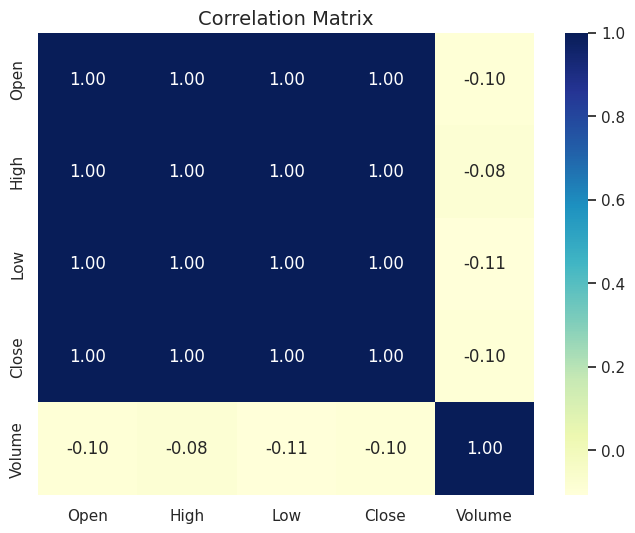

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["Open", "High", "Low", "Close", "Volume"]].corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Preprocessing

In [14]:
X = df.drop('High',axis = 1)
y = df['High']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
scaler = MinMaxScaler()
df["Volume-Scaled"] = scaler.fit_transform(df[["Volume"]])

print(df[["Volume" , 'Volume-Scaled']].head())

     Volume  Volume-Scaled
0  13181000       0.203625
1  17284900       0.275884
2  17948100       0.287562
3  11670000       0.177020
4   9689000       0.142140


# LSTM

In [17]:
def create_sequences(data , window_size):
    X,y = [],[]

    for i in range (len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X) , np.array(y)
window_size = 30 

X,y = create_sequences(df["Volume-Scaled"].values,window_size)
X = X.reshape(X.shape[0] , X.shape[1], 1)
split = int(0.8*len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (781, 30, 1)
X_test shape: (196, 30, 1)
y_train shape: (781,)
y_test shape: (196,)


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()
# Add LSTM layer; input_shape is (time_steps, features)
model.add(LSTM(units=50, return_sequences=True, input_shape=(30, 1)))
model.add(Dropout(0.2)) # Prevents overfitting
model.add(LSTM(units=50))
model.add(Dense(units=1)) # Final output layer


2026-06-04 05:21:26.492897: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
# Build the Model
model = keras.models.Sequential()
# Input Layer
model.add(keras.Input(shape=(X_train.shape[1], 1)))
# First Layer
model.add(keras.layers.LSTM(64, return_sequences=True))
# Second Layer
model.add(keras.layers.LSTM(64, return_sequences=False))
# 3rd Layer (Dense)
model.add(keras.layers.Dense(128, activation="relu"))
# 4th Layer (Dropout)
model.add(keras.layers.Dropout(0.5))
# Final Output Layer
model.add(keras.layers.Dense(1, activation="linear"))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer="adam",
    loss="mae",
    metrics=[keras.metrics.RootMeanSquaredError(name="rmse")]
)

In [21]:
fit = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), callbacks=[EarlyStopping(patience=60)])

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0784 - rmse: 0.1176 - val_loss: 0.0414 - val_rmse: 0.0786
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0561 - rmse: 0.0947 - val_loss: 0.0410 - val_rmse: 0.0771
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0585 - rmse: 0.0947 - val_loss: 0.0418 - val_rmse: 0.0788
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0550 - rmse: 0.0984 - val_loss: 0.0420 - val_rmse: 0.0735
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0535 - rmse: 0.0850 - val_loss: 0.0384 - val_rmse: 0.0744
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0560 - rmse: 0.0892 - val_loss: 0.0405 - val_rmse: 0.0772
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0528 - rmse: 0.0847 - val_loss: 0.0370 - val_rmse: 0.0707
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0563 - rmse: 0.1000 - val_loss: 0.0386 - val_rmse: 0.0726
Epoch 9/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/st

# Mean Absolute Error (MAE)

In [22]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# 1. Generate predictions first (Replace 'model' and 'X_test' with your actual names)
y_pred = model.predict(X_test) 

# 2. Now you can rescale them
y_pred_rescaled = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# 3. Calculate error metrics
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
print(f"Mean Absolute Error (MAE): {mae}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
Mean Absolute Error (MAE): 1953751.943877551
